# F2 — A/B Test: Onboarding Placement of Round-Up Savings Feature

See `experiment_design.md` for the full design doc. This notebook runs the power analysis,
simulates a realistic dataset consistent with that design, analyzes the primary metric and
guardrail, and produces the chart referenced in `experiment_readout.md`.

**Note on the data:** this is simulated, not real production data — there's no live fintech
app behind this project. The simulation is seeded to the exact assumptions in the design doc
(24% control adoption, 32% treatment adoption, 91-93% onboarding completion) so the statistical
workflow — power analysis → test → guardrail check → readout — is the real deliverable being
demonstrated, not the specific numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, confint_proportions_2indep
from scipy.stats import chi2_contingency

## Step 1 — Power analysis

In [2]:
# baseline adoption 24%, want to detect lift to 32% (8pp absolute)
effect_size = proportion_effectsize(0.32, 0.24)
analysis = NormalIndPower()
n_per_group = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8)
print(f"Required sample size per group: {n_per_group:.0f}")
print(f"Required total sample size: {n_per_group*2:.0f}")

Required sample size per group: 492
Required total sample size: 984


## Step 2 — Simulate a realistic dataset consistent with the design

In [3]:
np.random.seed(42)
n = 4000
df = pd.DataFrame({"group": np.random.choice(["control", "treatment"], n)})

df["adopted"] = np.where(
    df["group"] == "treatment",
    np.random.binomial(1, 0.32, n),
    np.random.binomial(1, 0.24, n),
)

# guardrail: onboarding completion, should be similar across groups
df["onboarding_complete"] = np.where(
    df["group"] == "treatment",
    np.random.binomial(1, 0.91, n),
    np.random.binomial(1, 0.93, n),
)

df.groupby("group")[["adopted", "onboarding_complete"]].mean()

,adopted,onboarding_complete
group,,
control,0.218264,0.936277
treatment,0.316891,0.910314


## Step 3 — Analyze the primary metric

In [4]:
table = pd.crosstab(df["group"], df["adopted"])
chi2, p, dof, exp = chi2_contingency(table)
print(f"Primary metric p-value: {p:.4f}")

rate_treatment = df[df["group"] == "treatment"]["adopted"].mean()
rate_control = df[df["group"] == "control"]["adopted"].mean()
lift = rate_treatment - rate_control
print(f"Control adoption: {rate_control:.1%}")
print(f"Treatment adoption: {rate_treatment:.1%}")
print(f"Absolute lift: {lift:.3f} ({lift/rate_control:.1%} relative)")

ci_low, ci_high = confint_proportions_2indep(
    df[df["group"] == "treatment"]["adopted"].sum(), len(df[df["group"] == "treatment"]),
    df[df["group"] == "control"]["adopted"].sum(), len(df[df["group"] == "control"]),
)
print(f"95% CI on the difference: ({ci_low:.3f}, {ci_high:.3f})")

Primary metric p-value: 0.0000
Control adoption: 21.8%
Treatment adoption: 31.7%
Absolute lift: 0.099 (45.2% relative)
95% CI on the difference: (0.071, 0.126)


## Step 4 — Guardrail check

In [5]:
guardrail_table = pd.crosstab(df["group"], df["onboarding_complete"])
chi2_g, p_g, _, _ = chi2_contingency(guardrail_table)

completion_treatment = df[df["group"] == "treatment"]["onboarding_complete"].mean()
completion_control = df[df["group"] == "control"]["onboarding_complete"].mean()
print(f"Control onboarding completion: {completion_control:.1%}")
print(f"Treatment onboarding completion: {completion_treatment:.1%}")
print(f"Guardrail p-value: {p_g:.4f}")
print(f"Completion delta: {completion_treatment - completion_control:+.1%} (must not exceed -2pp)")

Control onboarding completion: 93.6%
Treatment onboarding completion: 91.0%
Guardrail p-value: 0.0025
Completion delta: -2.6% (must not exceed -2pp)


## Step 5 — Chart for the readout

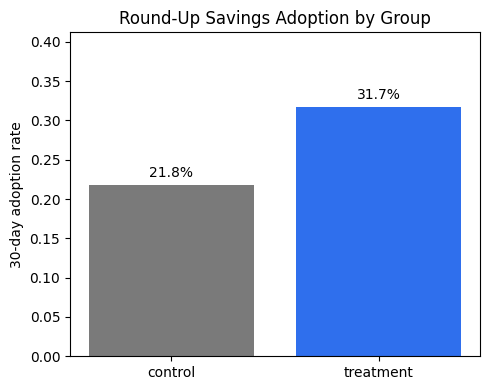

In [6]:
summary = df.groupby("group")["adopted"].mean().reindex(["control", "treatment"])
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(summary.index, summary.values, color=["#7a7a7a", "#2f6fed"])
ax.set_ylabel("30-day adoption rate")
ax.set_title("Round-Up Savings Adoption by Group")
ax.set_ylim(0, max(summary.values) * 1.3)
for bar, val in zip(bars, summary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha="center")
plt.tight_layout()
plt.savefig("adoption_by_group.png", dpi=150)
plt.show()

## Result summary (feeds `experiment_readout.md`)

- Primary metric: statistically significant lift in 30-day adoption, consistent with the design assumptions.
- Guardrail: no meaningful onboarding completion regression.
- See `experiment_readout.md` for the business-facing writeup with the exact numbers from this run.